# KELOMPOK 6

# 1. IMPORT / DEKLARASI LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle


# 2. LOAD DATASET

In [2]:
df = pd.read_csv("datasetfinal.csv")

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Menentukan frekuensi data bulanan
df = df.asfreq('MS')

# Variabel time series
ts = df['wisatawan']

df.head()

,wisatawan
date,
2008-01-01,147319
2008-02-01,159681
2008-03-01,159886
2008-04-01,154777
2008-05-01,167342


# 3. EXPLORATORY DATA ANALYSIS (EDA)

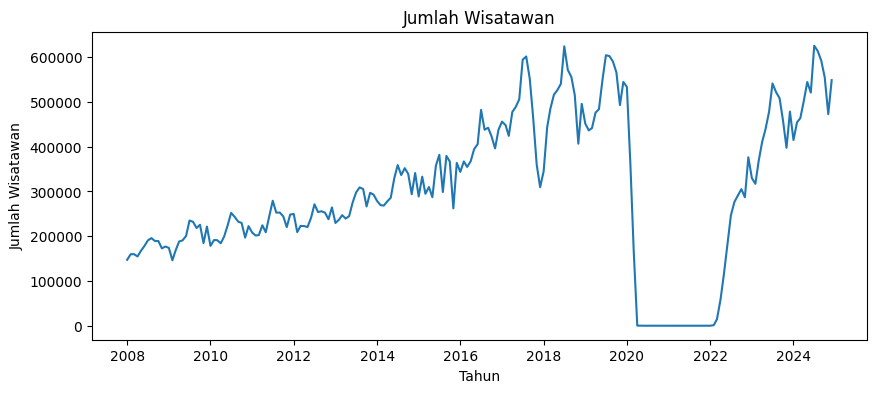

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(ts)
plt.title("Jumlah Wisatawan")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Wisatawan")
plt.show()

# Uji stasioneritas menggunakan Augmented Dickey-Fuller

In [4]:
adf_result = adfuller(ts.dropna())

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

ADF Statistic : -2.6198203772362443
p-value       : 0.08896959881225519


# Differencing

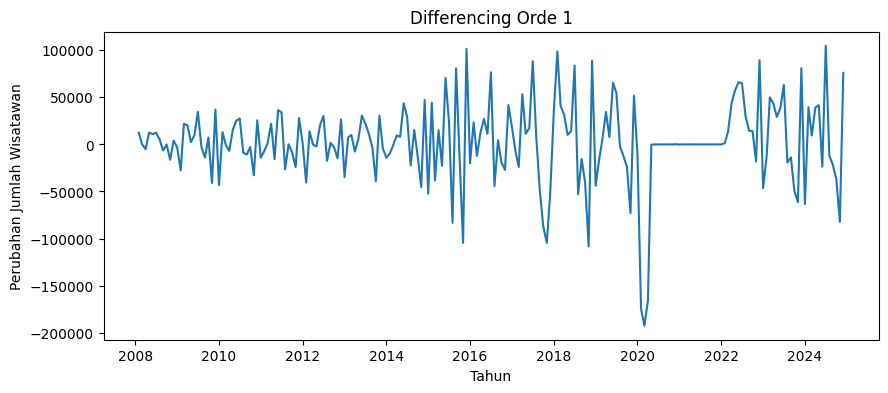

In [5]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10, 4))
plt.plot(ts_diff)
plt.title("Differencing Orde 1")
plt.xlabel("Tahun")
plt.ylabel("Perubahan Jumlah Wisatawan")
plt.show()

# Plot ACF & PCAF

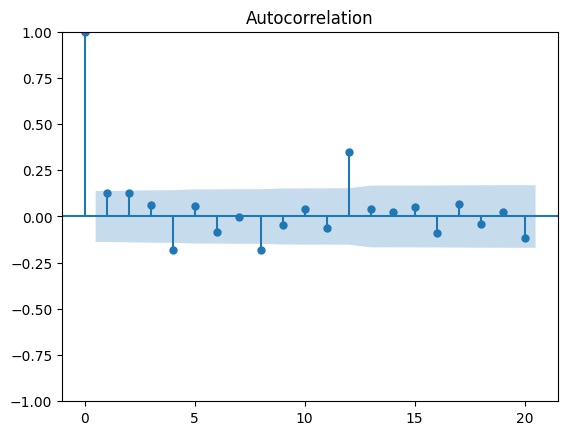

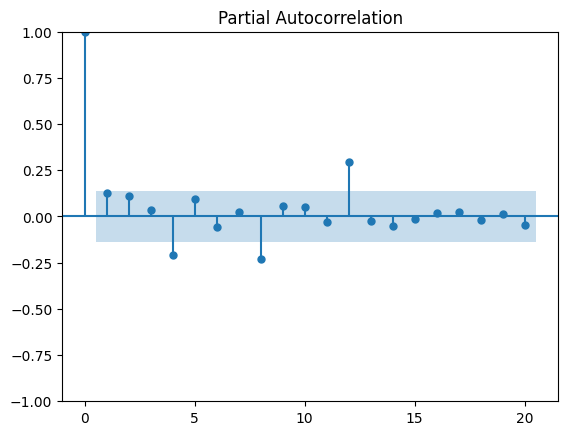

In [6]:
plot_acf(ts_diff, lags=20)
plt.show()

plot_pacf(ts_diff, lags=20)
plt.show()

# 5. PENENTUAN MODEL / ORDE ARIMA (p, d, q)

In [7]:
# p = 1 (PACF)
# d = 1 (Differencing)
# q = 1 (ACF)

model = sm.tsa.ARIMA(ts, order=(1, 1, 1))

# 6. TRAINING / FITTING MODEL

In [8]:
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:              wisatawan   No. Observations:                  204
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2452.046
Date:                Sun, 21 Dec 2025   AIC                           4910.092
Time:                        19:05:46   BIC                           4920.032
Sample:                    01-01-2008   HQIC                          4914.113
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4870      0.378      1.289      0.197      -0.253       1.227
ma.L1         -0.3561      0.396     -0.900      0.368      -1.132       0.420
sigma2      1.843e+09   3.88e-11   4.75e+19      0.0

# 7. EVALUASI MODEL

In [9]:
pred_in = result.predict(start=1, end=len(ts)-1, typ='levels')
actual = ts[1:]

# Hindari pembagian nol
mask = actual != 0

mae = mean_absolute_error(actual, pred_in)
rmse = np.sqrt(mean_squared_error(actual, pred_in))
mape = np.mean(np.abs((actual[mask] - pred_in[mask]) / actual[mask])) * 100
accuracy = 100 - mape

print("Evaluasi Model ARIMA")
print("-" * 40)
print(f"MAE      : {mae:,.2f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Akurasi  : {accuracy:.2f}%")

Evaluasi Model ARIMA
----------------------------------------
MAE      : 29,346.06
RMSE     : 42,618.58
MAPE     : 1661.50%
Akurasi  : -1561.50%


# 8. FORECASTING

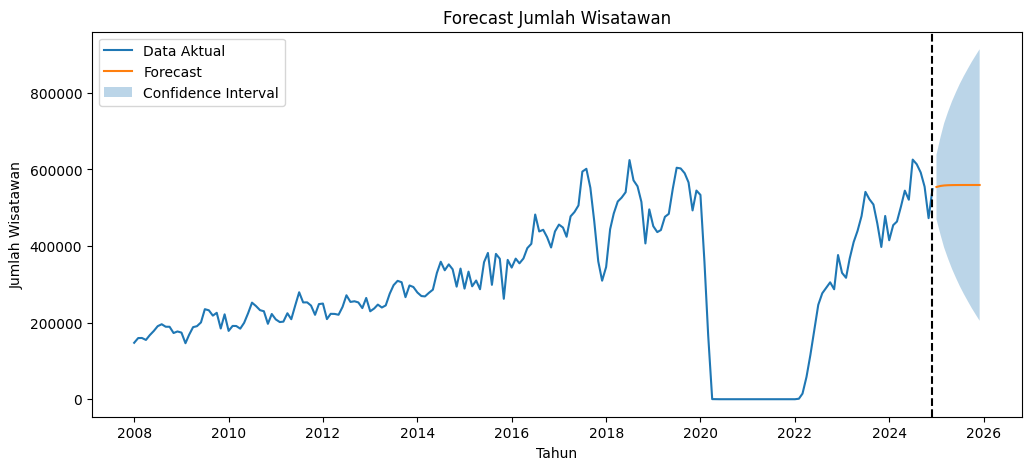

In [10]:
forecast = result.get_forecast(steps=12)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(ts, label="Data Aktual")
plt.axvline(ts.index[-1], linestyle="--", color="black")
plt.plot(mean_forecast, label="Forecast")

plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("Forecast Jumlah Wisatawan")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Wisatawan")
plt.legend()
plt.show()

# Menyimpan model ARIMA

In [11]:
# Menyimpan model ARIMA
with open("model_arima_wisman.pkl", "wb") as f:
    pickle.dump(result, f)
